# Final product 3: Two polygon comparison.

In this example, we show how to estimate the amount of information shared between two WKT polygons provided by the user in a free-cloud composite of Sentinel-2.

In [1]:
import geopandas as gpd
import math
import pandas as pd
from shapely.geometry import Point, Polygon
from shapely.wkt import loads
import os
import dask
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy
import zarr
import re
import gc

In [2]:
# to install geopy, open a terminal then:
# conda activate sentinelhub
# pip install geopy
import geopy.distance

In [3]:
# We will use xcube to access Sentinel-2 imagery and create a lazy xarray cube
from xcube.core.store import new_data_store


A spatial extent is a bounding box that specifies the minimum and maximum longitude and latitude of the region of interest you want to process.

By default, this latitude, and longitude values are expressed in the standard Coordinate Reference System for the world, which is EPSG:4623, also known as “WGS 84”, or just “lat-long”.

In this example, we will use the coordinates of the EC tower DE-Lnf

https://fluxnet.org/sites/siteinfo/DE-Lnf


In [4]:
from pyproj import CRS, Transformer
from shapely.geometry import Point
from shapely.ops import transform

def geodesic_point_buffer(lat, lon, km):
    # Azimuthal equidistant projection
    aeqd_proj = CRS.from_proj4(
        f"+proj=aeqd +lat_0={lat} +lon_0={lon} +x_0=0 +y_0=0")
    tfmr = Transformer.from_proj(aeqd_proj, aeqd_proj.geodetic_crs)
    buf = Point(0, 0).buffer(km * 1000)  # distance in metres
    arr = np.array(transform(tfmr.transform, buf).exterior.coords[:])
    
    return [arr[:,0].min(), arr[:,1].min(), arr[:,0].max(), arr[:,1].max()]


We will create a bounding box based on a point and a radius in kilometers. In this example, the coordinates of the DE-Lnf tower are ```51.3282, 10.3678```, and the radius is ```10``` kilometers.

In [5]:
bbox = geodesic_point_buffer(51.3282, 10.3678, 10)
bbox

[10.224330799068323, 51.23831534516407, 10.511269200931679, 51.41808326764632]

We also need to define the time range of images that will be used to create the cloud-free image composite. In this case:

In [6]:
time_range = ('2023-03-01', '2023-09-01')

CDSE credentials for Sentinelhub, for more informantion see:

* How can I generate the credentials:
https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html

* How can I use xcube with SentinelHub:
https://xcube.readthedocs.io/en/latest/api.html#xcube.core.store.new_data_store


In [7]:
sh_config = dict(client_id = '',
                 client_secret =  '',
                 oauth2_url = 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect',
                 api_url = 'https://sh.dataspace.copernicus.eu')

In [8]:
store = new_data_store('sentinelhub', **sh_config)

In [9]:
dataset = store.open_data('S2L2A',
                         variable_names = ['B07', 'B03', 'SCL'],
                         bbox = bbox,
                         spatial_res = 0.00018,
                          downsampling="BILINEAR", upsampling="BICUBIC",
                         time_range = time_range,
                                 chunks={'time': -1, 
                                         'lat':-1,
                                        'lon':-1})

/opt/conda/envs/sentinelhub/lib/python3.10/site-packages/xcube_sh/sentinelhub.py:254: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt = pd.to_datetime(dt, infer_datetime_format=True, utc=True)
/opt/conda/envs/sentinelhub/lib/python3.10/site-packages/xcube_sh/sentinelhub.py:317: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  pd.to_timedelta(max_timedelta)


In [10]:
dataset

<xarray.Dataset>
Dimensions:    (time: 73, lat: 999, lon: 1594, bnds: 2)
Coordinates:
  * lat        (lat) float64 51.42 51.42 51.42 51.42 ... 51.24 51.24 51.24 51.24
  * lon        (lon) float64 10.22 10.22 10.22 10.22 ... 10.51 10.51 10.51 10.51
  * time       (time) datetime64[ns] 2023-03-02T10:26:39 ... 2023-08-29T10:26:43
    time_bnds  (time, bnds) datetime64[ns] dask.array<chunksize=(73, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    B03        (time, lat, lon) float32 dask.array<chunksize=(73, 999, 1594), meta=np.ndarray>
    B07        (time, lat, lon) float32 dask.array<chunksize=(73, 999, 1594), meta=np.ndarray>
    SCL        (time, lat, lon) uint8 dask.array<chunksize=(73, 999, 1594), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   S2L2A Data Cube Subset
    history:                 [{'program': 'xcube_sh.chunkstore.SentinelHubChu...
    date_created:            2024-09-03T15:01:54.767818
    time_coverage_start:     2023-03-02T10:26:30.227000+00:00
    time_coverage_end:       2023-08-29T10:26:52.038000+00:00
    time_coverage_duration:  P180DT0H0M21.811S
    geospatial_lon_min:      10.224330799068323
    geospatial_lat_min:      51.23831534516407
    geospatial_lon_max:      10.511250799068323
    geospatial_lat_max:      51.41813534516407
    processing_level:        L2A

### Visual inspection of the cube

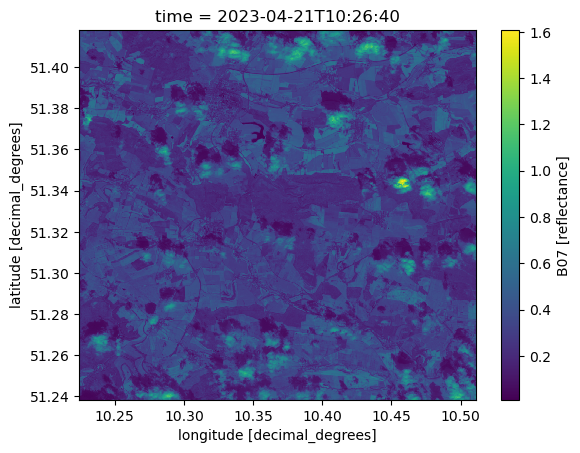

In [11]:
# Band B7
dataset['B07'].sel(time = "2023-04-21").plot()

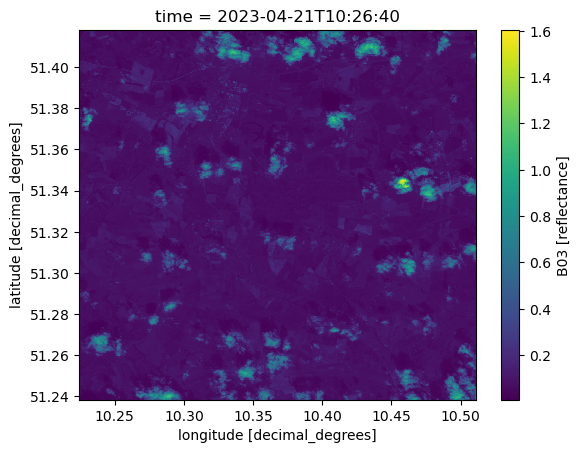

In [23]:
# Band B3
dataset['B03'].sel(time = "2023-04-21").plot()

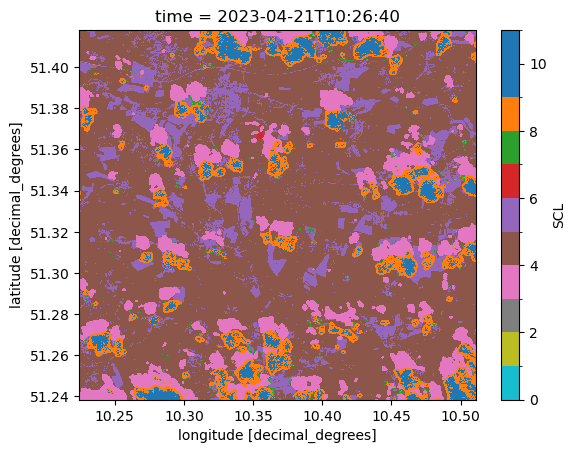

In [24]:
# Scene classification
dataset['SCL'].sel(time = '2023-04-21').plot(levels=[0, 1, 2,3,4,5,6,7,8,9,10,11], colors = 'tab10_r')

### Masking based on the SCL variable

In this exercise we will focus only on the differences of earth surface where we have good observations without clouds or clouds shadows, Then we will only consider the classes ```4,5,6,11``` corresponding to: 

4 => vegetation

5 => bare_soils

6 => water

11 => snow_or_ice

For more details on the Scene classes run ```store.describe_data('S2L2A')```

In [25]:
dataset_filtered = dataset.where(dataset['SCL'].isin([4,5,6,11]))

### Creating the composite

In [26]:
dataset_filtered = dataset_filtered.mean(dim = 'time', skipna = True)

### Computing Red-edge chlorophyll index (CIR)

In [32]:
cir = (dataset_filtered['B07'] /  dataset_filtered['B03']) - 1

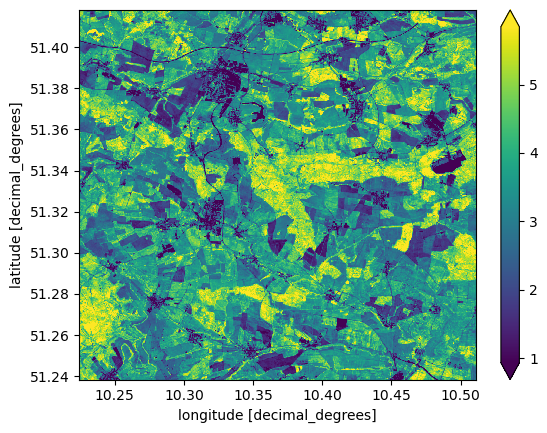

In [28]:
# Visual inspection of the CIR
cir.plot(robust=True)

In [35]:
cir.rio.write_crs("EPSG:4326", inplace=True)

<xarray.DataArray (lat: 999, lon: 1594)>
dask.array<sub, shape=(999, 1594), dtype=float32, chunksize=(999, 1594), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float64 51.42 51.42 51.42 51.42 ... 51.24 51.24 51.24
  * lon          (lon) float64 10.22 10.22 10.22 10.22 ... 10.51 10.51 10.51
    spatial_ref  int64 0

### Reading and comparing two WKT Polygons

To mask values corresponding to each polygon

In [31]:
# Example WKT polygons (replace with your actual WKT strings)
wkt_polygons = [
    "POLYGON ((10.37584 51.30017, 10.43545 51.31752, 10.40683 51.36473, 10.34718 51.34737, 10.37584 51.30017))",
    "POLYGON ((10.36846 51.29958, 10.42575 51.30629, 10.40720 51.35493, 10.34985 51.34821, 10.36846 51.29958))"
]

### Estimating Jensen-Shannon distance from polygon1 to polygon2



In [37]:
polygon1 = loads(wkt_polygons[0])
polygon2 = loads(wkt_polygons[1])

subseting the cube using each polygon

In [38]:
cube_pol_1 = cir.rio.clip([polygon1], cir.rio.crs, drop=False)
cube_pol_2 = cir.rio.clip([polygon2], cir.rio.crs, drop=False)

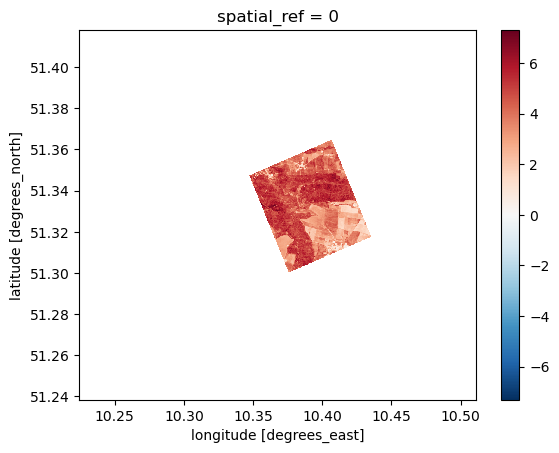

In [41]:
cube_pol_1.plot()

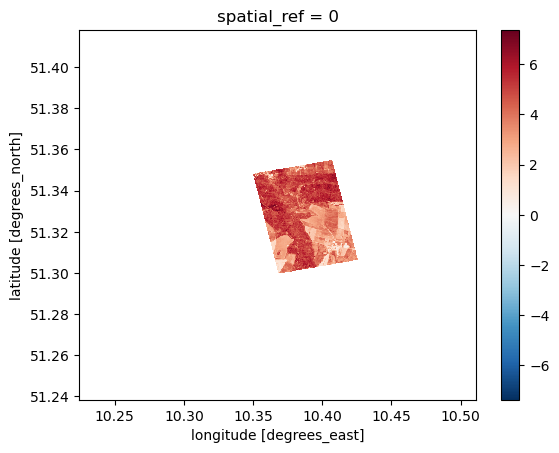

In [43]:
cube_pol_2.plot()

computing jensen-shannon

In [45]:
data_pol_1 = cube_pol_1.values.flatten()
data_pol_1 = data_pol_1[~np.isnan(data_pol_1)]

data_pol_2 = cube_pol_2.values.flatten()
data_pol_2 = data_pol_2[~np.isnan(data_pol_2)]

# Estimate the KDE for each vector
kde1 = scipy.stats.gaussian_kde(data_pol_1)
kde2 = scipy.stats.gaussian_kde(data_pol_2)

# Create a range of values for the x-axis
x_values = np.linspace(min(data_pol_1.min(), data_pol_2.min()), max(data_pol_1.max(), data_pol_2.max()), 100)

# Get the KDE values at specific points for each vector
kde_values1 = kde1.evaluate(x_values)
kde_values2 = kde2.evaluate(x_values)
    
results = scipy.spatial.distance.jensenshannon(kde_values1, kde_values2)

When Jensen-Shannon is 0: Both distributions share the same information. When Jensen-Shannon is 1: The distributions does not share any information

In [46]:
print(results)

0.03683585997969846
